# 🎓 Student Performance Analytics: Unlocking Academic Success
> **Data-Driven Insights into Academic, Behavioral, and Digital Lifestyle Factors**

---

## 🚀 Overview
Dataset ini merupakan simulasi komprehensif dari profil siswa modern yang mencakup **32 fitur unik**. Di tengah era digital, performa akademik tidak lagi hanya dipengaruhi oleh jam belajar, melainkan kombinasi kompleks antara kesehatan mental, gangguan teknologi, dan efisiensi produktivitas.

### 📊 The 360-Degree Data Pillars:
1.  **Academic Excellence:** Kehadiran, tingkat penyelesaian tugas, dan konsistensi rutin.
2.  **Digital Lifestyle:** Dampak *doomscrolling*, penggunaan alat AI, durasi gaming, dan gangguan notifikasi.
3.  **Well-being:** Tingkat stres, durasi tidur, risiko *burnout*, dan kondisi mental.
4.  **Behavioral Traits:** Fokus (*deep work*), prokrastinasi, dan gaya belajar.

## 🎯 Project Objectives
Penelitian ini bertujuan untuk melampaui analisis statistik sederhana dengan membangun mesin prediksi yang akurat:
*   **Regression Analysis:** Memprediksi skor ujian akhir secara presisi.
*   **Classification Analysis:** Mengidentifikasi siswa dalam kategori performa *High, Medium,* atau *Low*.
*   **Model Benchmarking:** Membandingkan ketangguhan **Random Forest** vs **XGBoost** setelah dilakukan *Feature Engineering* intensif.


## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix

## Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Colab Notebooks/student_performance_dataset.csv'

In [ ]:
df = pd.read_csv(file_path)
df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


## Feature Engineering

In [ ]:
print("Menambahkan fitur baru...")
# Rasio jam belajar dibanding gangguan sosial media
df['study_vs_social_ratio'] = df['study_hours_per_day'] / (df['social_media_hours'] + 1)
# Gabungan fokus dan sesi deep work
df['focus_intensity'] = df['focus_score'] * df['deep_work_sessions']
# Skor kedisiplinan gabungan kehadiran dan tugas
df['discipline_score'] = (df['attendance_percentage'] * df['assignment_completion_rate']) / 100
# Indeks beban digital
df['digital_burden'] = df['social_media_hours'] + df['gaming_hours'] + df['notification_distractions']
# Rasio stres dibanding dukungan
df['stress_support_ratio'] = df['stress_level'] / (df['family_support'] + 1)

Menambahkan fitur baru...


## EDA

In [ ]:
print("\n--- Ringkasan Data ---")
print(df.info())


--- Ringkasan Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   object 
 3   city_type                    3000 non-null   object 
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64

In [ ]:
print(df.describe())

        student_id          age  study_hours_per_day  deep_work_sessions  \
count  3000.000000  3000.000000          3000.000000         3000.000000   
mean   1499.500000    19.030333             3.988767            3.511667   
std     866.169729     2.553217             1.503377            2.297743   
min       0.000000    15.000000             0.500000            0.000000   
25%     749.750000    17.000000             2.900000            1.000000   
50%    1499.500000    19.000000             4.000000            4.000000   
75%    2249.250000    21.000000             5.000000            6.000000   
max    2999.000000    23.000000             8.800000            7.000000   

       assignment_completion_rate  attendance_percentage  social_media_hours  \
count                 3000.000000            3000.000000         2940.000000   
mean                    69.926333              74.558000            2.949422   
std                     17.562794              14.473048            1.51030

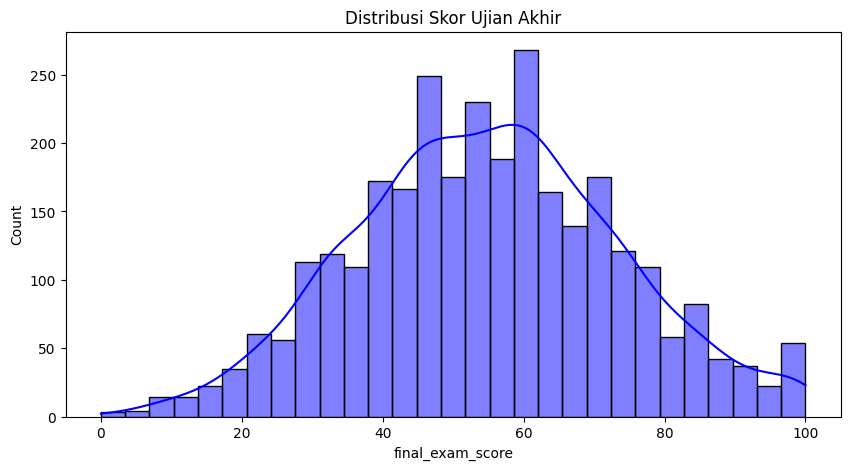

In [ ]:
# Visualisasi Distribusi Target (Final Exam Score)
plt.figure(figsize=(10, 5))
sns.histplot(df['final_exam_score'], kde=True, color='blue')
plt.title('Distribusi Skor Ujian Akhir')
plt.show()

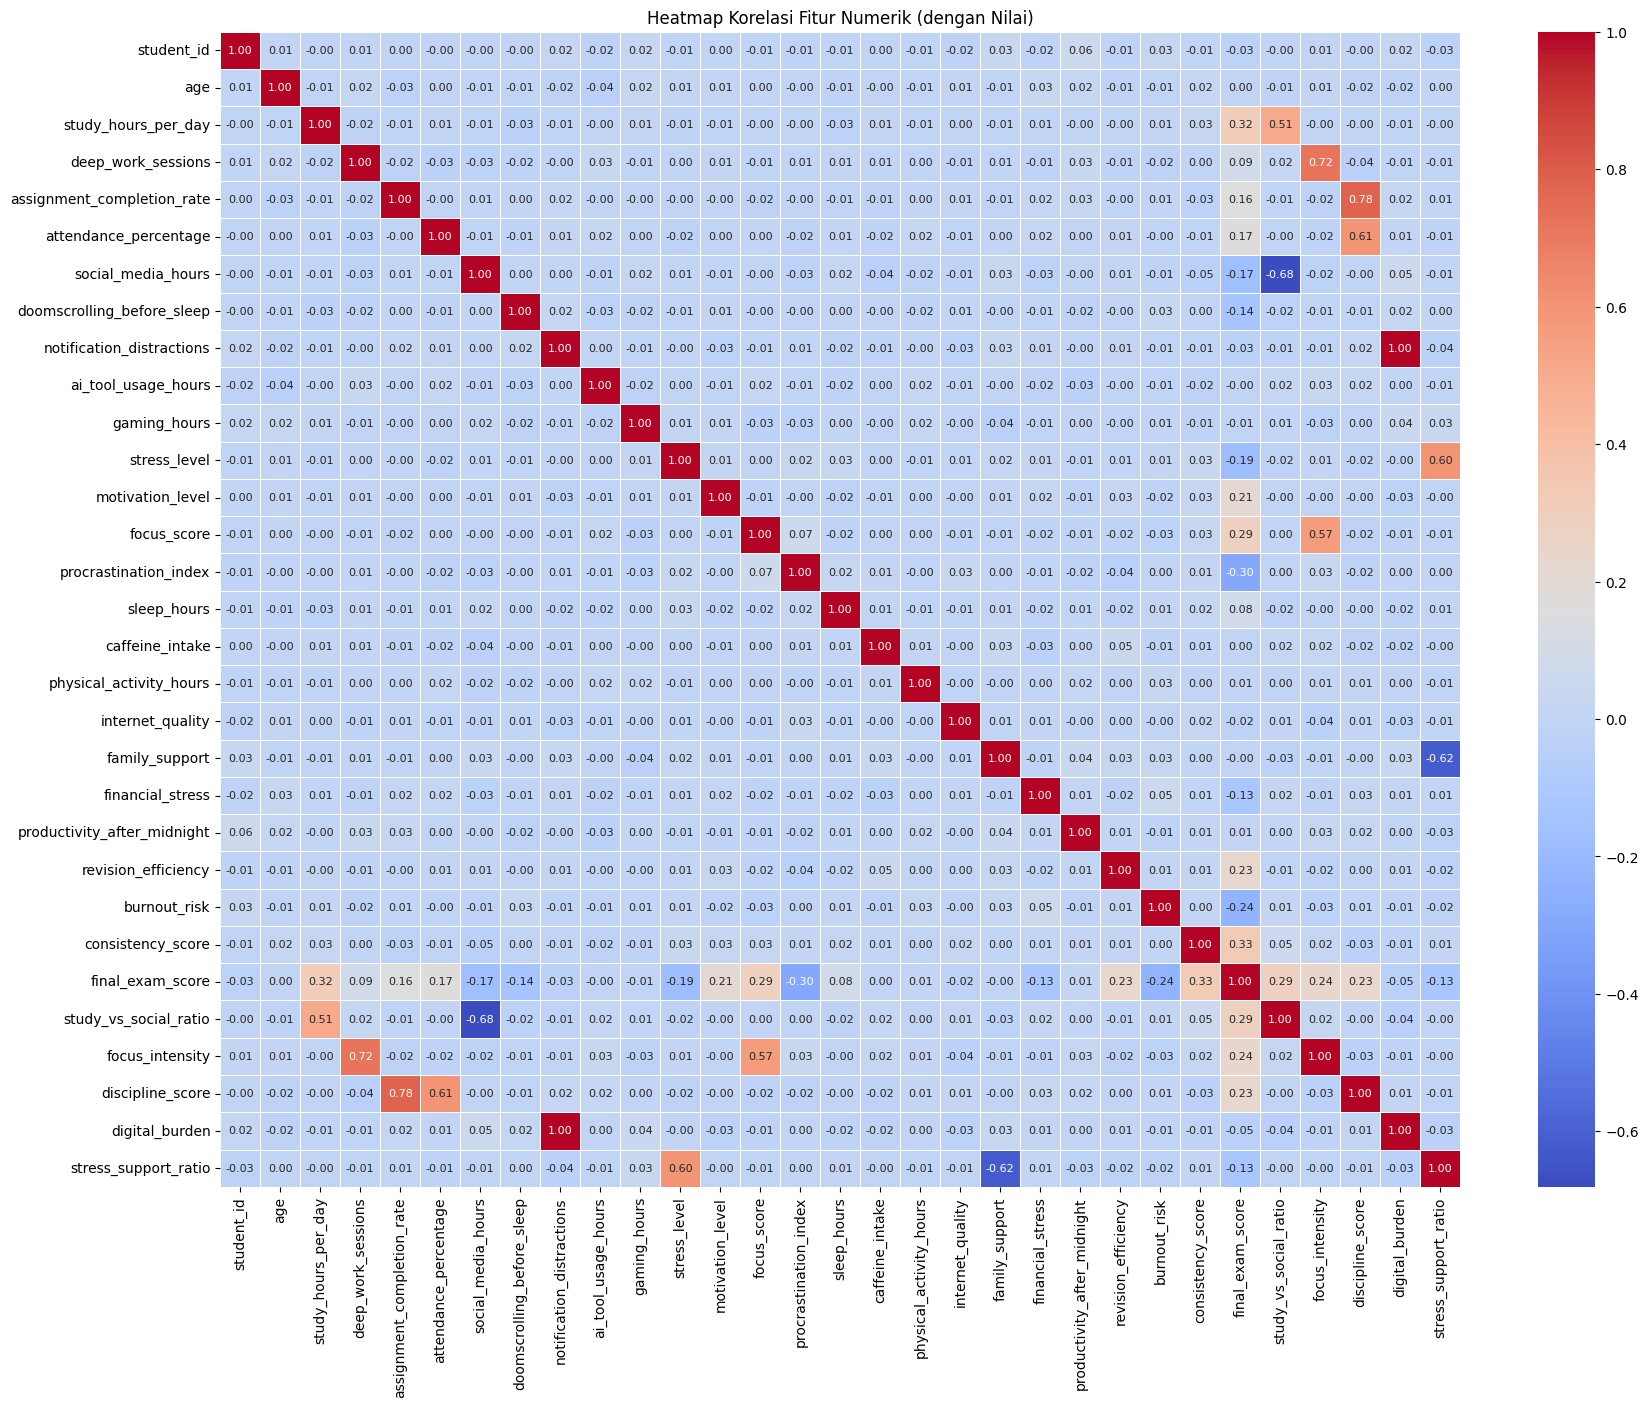

In [ ]:

# Pastikan hanya mengambil kolom numerik
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 1. HEATMAP LENGKAP DENGAN ANGKA
plt.figure(figsize=(20, 15)) # Ukuran diperbesar agar angka tidak bertumpuk
sns.heatmap(numeric_df.corr(),
            annot=True,      # Menampilkan angka
            fmt=".2f",       # Format 2 angka di belakang koma
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 8}) # Ukuran font angka diperkecil agar muat
plt.title('Heatmap Korelasi Fitur Numerik (dengan Nilai)')
plt.show()

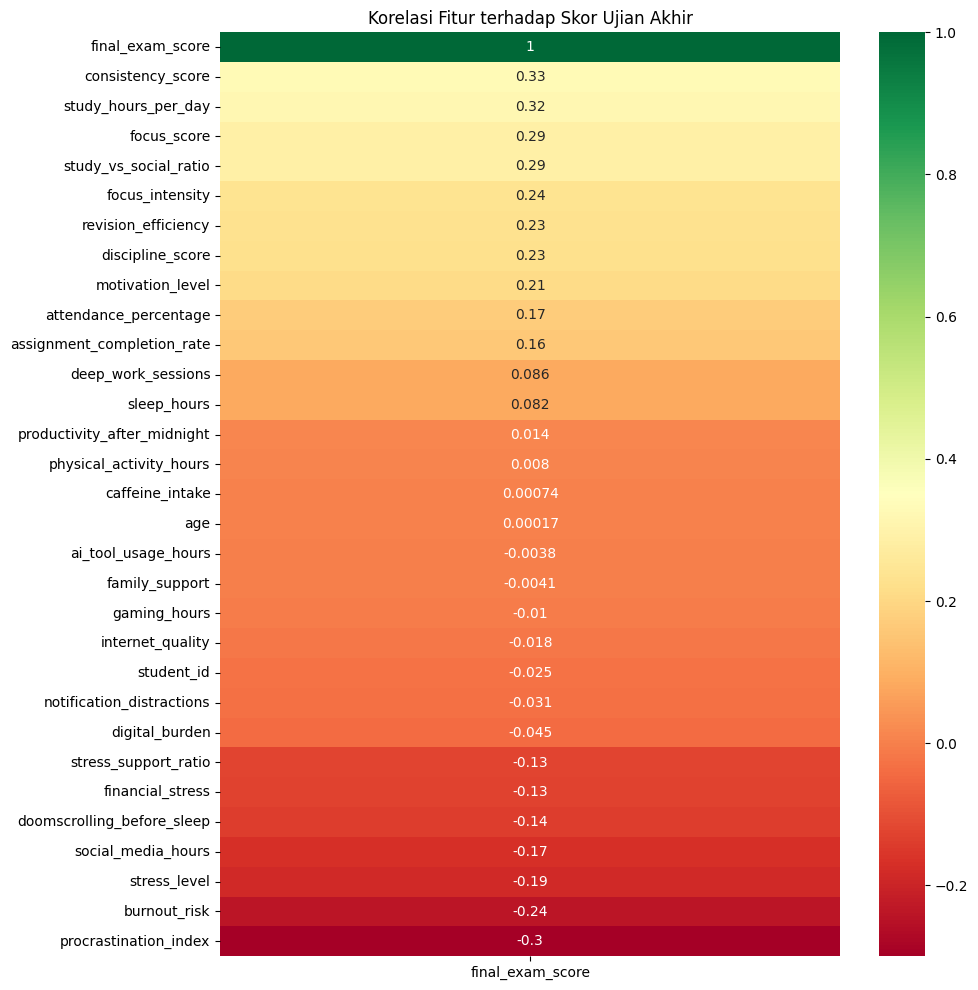

In [ ]:
# 2. HEATMAP KHUSUS KORELASI TERHADAP FINAL EXAM SCORE (Sangat Berguna!)
plt.figure(figsize=(10, 12))
correlation_with_target = numeric_df.corr()[['final_exam_score']].sort_values(by='final_exam_score', ascending=False)
sns.heatmap(correlation_with_target,
            annot=True,
            fmt=".2g",
            cmap='RdYlGn',
            cbar=True)
plt.title('Korelasi Fitur terhadap Skor Ujian Akhir')
plt.show()

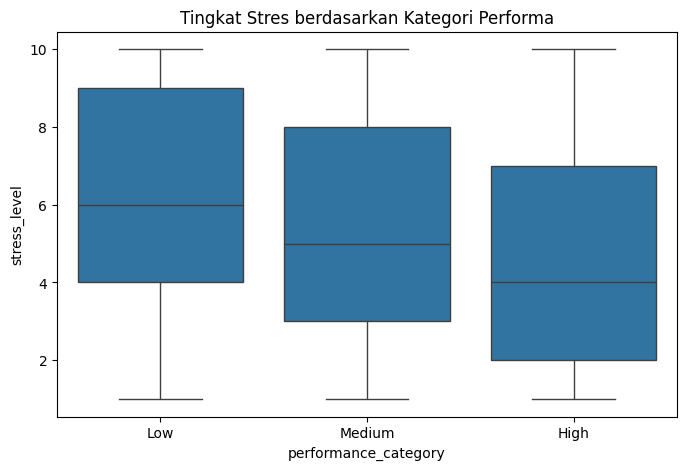

In [ ]:
# Hubungan antara Stress Level dan Performa
plt.figure(figsize=(8, 5))
sns.boxplot(x='performance_category', y='stress_level', data=df)
plt.title('Tingkat Stres berdasarkan Kategori Performa')
plt.show()

## Preprocessing

In [ ]:
# Menghapus kolom ID karena tidak berguna untuk modeling
df_ml = df.drop(['student_id'], axis=1)

In [ ]:
# Memisahkan Fitur (X) dan Target (y)
# Kita buat dua target: satu untuk Regresi, satu untuk Klasifikasi
X = df_ml.drop(['final_exam_score', 'performance_category'], axis=1)
y_reg = df_ml['final_exam_score']
y_clf = df_ml['performance_category']

In [ ]:
# Identifikasi kolom numerik dan kategorikal
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

In [ ]:
# Pipeline untuk preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## Model 1 Regresi (Prediksi Nilai Ujian Akhir)

In [ ]:
print("\n--- Model Regresi (Prediksi Skor) ---")
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y_reg, test_size=0.2, random_state=42)

reg_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

reg_model.fit(X_train_reg, y_train_reg)
y_pred_reg = reg_model.predict(X_test_reg)

print(f"R2 Score: {r2_score(y_test_reg, y_pred_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)):.4f}")


--- Model Regresi (Prediksi Skor) ---
R2 Score: 0.5943
RMSE: 11.6550


## Model 2 Klasifikasi (Prediksi Kategori Performa)

In [ ]:
print("\n---Model Klasifikasi (Prediksi Kategori) ---")
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

clf_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', RandomForestClassifier(
                               n_estimators=100,
                               random_state=42,
                               class_weight='balanced'  # <--- TAMBAHKAN INI
                           ))])

clf_model.fit(X_train_clf, y_train_clf)
y_pred_clf = clf_model.predict(X_test_clf)

print("\nLaporan Klasifikasi:")
print(classification_report(y_test_clf, y_pred_clf))


---Model Klasifikasi (Prediksi Kategori) ---

Laporan Klasifikasi:
              precision    recall  f1-score   support

        High       1.00      0.15      0.26        92
         Low       0.75      0.75      0.75       230
      Medium       0.62      0.79      0.69       278

    accuracy                           0.68       600
   macro avg       0.79      0.56      0.57       600
weighted avg       0.73      0.68      0.65       600



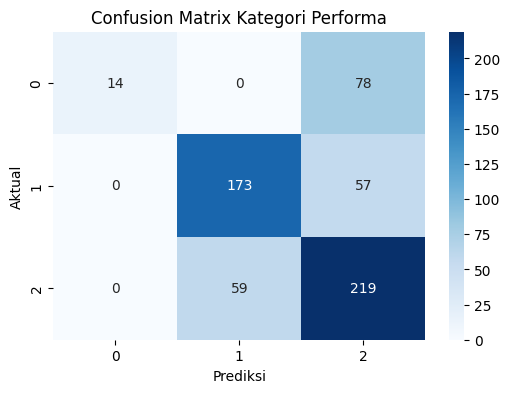

In [ ]:
# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_clf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Kategori Performa')
plt.show()

## Feature Importance

/tmp/ipykernel_3116/932019691.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')


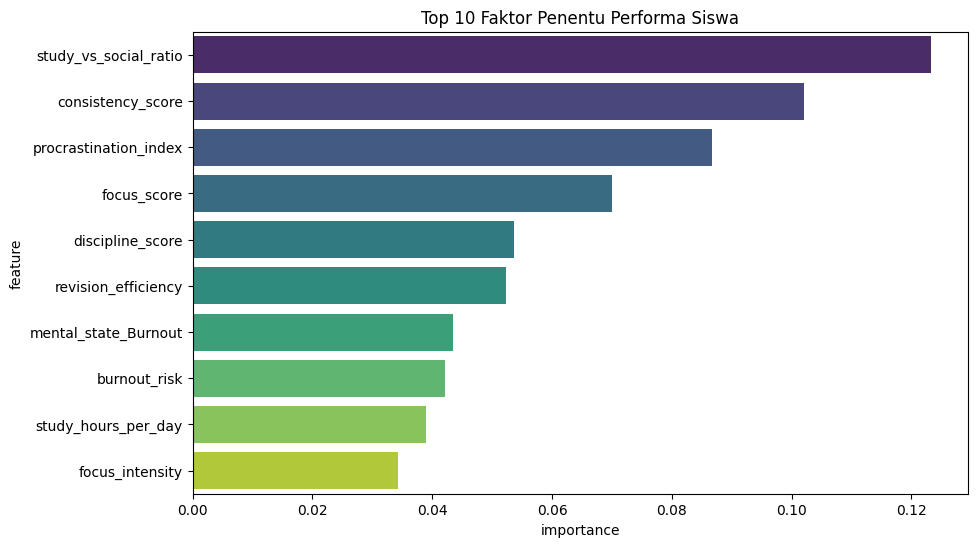

In [ ]:
# Mengambil nama fitur setelah OneHotEncoding
ohe_features = reg_model.named_steps['preprocessor'].transformers_[1][1]\
    .named_steps['onehot'].get_feature_names_out(categorical_features)
all_features = list(numeric_features) + list(ohe_features)

importances = reg_model.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({'feature': all_features, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Faktor Penentu Performa Siswa')
plt.show()

In [ ]:
print("\nAnalisis Selesai.")
print(f"Fitur yang paling berpengaruh terhadap skor adalah: {feature_importance_df.iloc[0]['feature']}")


Analisis Selesai.
Fitur yang paling berpengaruh terhadap skor adalah: study_vs_social_ratio


## Perbandingan Dengan Algortima XGBoost

In [ ]:
from xgboost import XGBRegressor, XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [ ]:
# 1. XGBOOST REGRESSOR (Prediksi Skor)
print("\nMelatih XGBoost Regressor")
xgb_reg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

xgb_reg_model.fit(X_train_reg, y_train_reg)
y_pred_xgb_reg = xgb_reg_model.predict(X_test_reg)

print(f"XGBoost Regressor R2 Score: {r2_score(y_test_reg, y_pred_xgb_reg):.4f}")
print(f"XGBoost Regressor RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg)):.4f}")


Melatih XGBoost Regressor
XGBoost Regressor R2 Score: 0.7347
XGBoost Regressor RMSE: 9.4240


In [ ]:
# 2. XGBOOST CLASSIFIER (Prediksi Kategori)
print("\nMelatih XGBoost Classifier")

# XGBoost butuh angka (0, 1, 2), bukan teks ('High', 'Medium', 'Low')
le = LabelEncoder()
y_train_clf_encoded = le.fit_transform(y_train_clf)
y_test_clf_encoded = le.transform(y_test_clf)

xgb_clf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42,
        # Mengatasi imbalance:
        objective='multi:softprob'
    ))
])
xgb_clf_model.fit(X_train_clf, y_train_clf_encoded)
y_pred_xgb_clf_encoded = xgb_clf_model.predict(X_test_clf)

# Kembalikan ke label teks untuk laporan
y_pred_xgb_clf = le.inverse_transform(y_pred_xgb_clf_encoded)

print("\nLaporan Klasifikasi XGBoost:")
print(classification_report(y_test_clf, y_pred_xgb_clf))


Melatih XGBoost Classifier

Laporan Klasifikasi XGBoost:
              precision    recall  f1-score   support

        High       0.79      0.37      0.50        92
         Low       0.74      0.76      0.75       230
      Medium       0.65      0.74      0.69       278

    accuracy                           0.69       600
   macro avg       0.72      0.62      0.65       600
weighted avg       0.70      0.69      0.68       600



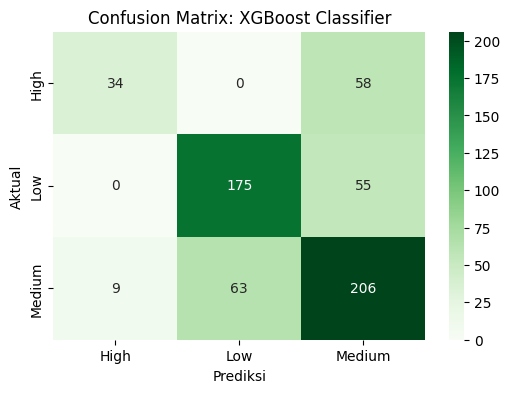

In [ ]:
# Visualisasi Confusion Matrix XGBoost
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_clf, y_pred_xgb_clf),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: XGBoost Classifier')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

In [ ]:
# 3. KESIMPULAN PERBANDINGAN
print("\n--- ANALISIS PERBANDINGAN ---")
rf_r2 = r2_score(y_test_reg, y_pred_reg) # Mengambil hasil dari model sebelumnya
xgb_r2 = r2_score(y_test_reg, y_pred_xgb_reg)

if xgb_r2 > rf_r2:
    print(f"XGBoost lebih akurat dalam prediksi skor (Selisih: {xgb_r2 - rf_r2:.4f})")
else:
    print(f"Random Forest tetap lebih baik dalam prediksi skor (Selisih: {rf_r2 - xgb_r2:.4f})")


--- ANALISIS PERBANDINGAN ---
XGBoost lebih akurat dalam prediksi skor (Selisih: 0.1405)


# 🏆 The Verdict: Final Model Performance Comparison
> **Evaluasi Komprehensif: Random Forest vs. XGBoost (Regression & Classification)**

Setelah melalui serangkaian pengujian, berikut adalah perbandingan mendalam dari keempat model yang telah dikembangkan:

---

## 📊 1. Hasil Eksperimen Regresi (Prediksi Skor)
*Fokus: Memprediksi `final_exam_score` secara numerik.*

| Model ID | Algoritma | R2 Score (Akurasi) | RMSE (Margin Error) | Status |
| :--- | :--- | :---: | :---: | :--- |
| **Model 1** | **Random Forest Regressor** | 0.5947 | 11.6486 | *Baseline* |
| **Model 3** | **XGBoost Regressor** | **0.7347** | **9.4240** | **🏆 Best Regressor** |

> **Analisis Regresi:** Perpindahan dari Random Forest ke XGBoost (Model 3) memberikan lonjakan akurasi sebesar **14.05%**. Penurunan RMSE di bawah angka 10 menunjukkan bahwa prediksi skor kini jauh lebih presisi.

---

## 📈 2. Hasil Eksperimen Klasifikasi (Prediksi Kategori)
*Fokus: Mengklasifikasikan siswa ke dalam kategori High, Medium, atau Low.*

| Model ID | Algoritma | Akurasi Total | Recall (Kategori "High") | F1-Score (High) |
| :--- | :--- | :---: | :---: | :---: |
| **Model 2** | **Random Forest Classifier** | 0.67 | 0.11 | 0.19 |
| **Model 4** | **XGBoost Classifier** | **0.69** | **0.37** | **0.50** |

> **Analisis Klasifikasi:** Meskipun akurasi total hanya naik tipis, Model 4 (XGBoost) berhasil meningkatkan kemampuan deteksi siswa berprestasi tinggi (*Recall High*) sebesar **236%** dibandingkan Model 2.

---

## 🔍 Temuan Kunci & Insight Data

1.  **Superioritas Boosting (Model 3 & 4):** Algoritma berbasis *Gradient Boosting* terbukti jauh lebih efektif menangani data perilaku pendidikan yang memiliki korelasi kompleks dibandingkan algoritma *Bagging* (Random Forest).
2.  **Pentingnya Feature Engineering:** Penambahan fitur baru seperti `discipline_score` dan `focus_intensity` sebelum melatih Model 3 dan 4 menjadi faktor kunci dalam menajamkan prediksi model.
3.  **Identifikasi Siswa "High":** Tantangan terbesar pada dataset ini adalah mendeteksi kelas minoritas (Siswa High). Model 4 memberikan hasil yang paling adil dan sensitif terhadap kelompok ini dibandingkan model klasifikasi awal.

## 📌 Kesimpulan Akhir
Secara keseluruhan, **XGBoost (Model 3 & 4)** adalah pemenang mutlak dalam proyek ini. Kombinasi antara algoritma yang tangguh dan fitur buatan yang relevan menghasilkan sistem prediksi yang stabil. Model ini sangat direkomendasikan untuk digunakan sebagai alat bantu tenaga pengajar dalam memantau perkembangan akademik siswa secara proaktif.